In [1]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [36]:
df= pd.read_csv("/kaggle/input/datasets/hansicooray/tennis-data/atp_tennis_processed_2010_2024.csv")
print(df.shape)
df.tail(3)

(42571, 19)


,Match_Date,Tournament_Name,Tournament_Tier,Prestige_Score,Round,Round_Name,Round_Multiplier,Match_Format,Winner_ID,Winner_Name,Winner_Rank,Loser_ID,Loser_Name,Loser_Rank,Score,Games_Diff,Sets_Diff,Surface,Best_of
42568,2024-12-18,Next Gen Finals,Tour Finals,1.8,RR,Round Robin,0.65,Bo5,P_210506,Alex Michelsen,41.0,P_210460,Nishesh Basavareddy,138.0,2-4 4-3(5) 4-3(4) 4-2,0,0,Hard,5
42569,2024-12-18,Next Gen Finals,Tour Finals,1.8,RR,Round Robin,0.65,Bo5,P_210506,Alex Michelsen,41.0,P_209992,Juncheng Shang,50.0,4-1 1-1 RET,3,0,Hard,5
42570,2024-12-18,Next Gen Finals,Tour Finals,1.8,RR,Round Robin,0.65,Bo5,P_211663,Joao Fonseca,145.0,P_209950,Arthur Fils,20.0,3-4(9) 4-2 4-1 1-4 4-1,5,2,Hard,5


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42571 entries, 0 to 42570
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Match_Date        42571 non-null  object 
 1   Tournament_Name   42571 non-null  object 
 2   Tournament_Tier   42571 non-null  object 
 3   Prestige_Score    42571 non-null  float64
 4   Round             42571 non-null  object 
 5   Round_Name        42571 non-null  object 
 6   Round_Multiplier  42571 non-null  float64
 7   Match_Format      42571 non-null  object 
 8   Winner_ID         42571 non-null  object 
 9   Winner_Name       42571 non-null  object 
 10  Winner_Rank       42309 non-null  float64
 11  Loser_ID          42571 non-null  object 
 12  Loser_Name        42571 non-null  object 
 13  Loser_Rank        41900 non-null  float64
 14  Score             42571 non-null  object 
 15  Games_Diff        42571 non-null  int64  
 16  Sets_Diff         42571 non-null  int64 

,Prestige_Score,Round_Multiplier,Winner_Rank,Loser_Rank,Games_Diff,Sets_Diff,Best_of
count,42571.000000,42571.000000,42309.000000,41900.000000,42571.000000,42571.000000,42571.000000
mean,1.411407,0.480645,75.455600,112.968592,4.735970,1.497381,3.437716
std,0.297916,0.182173,130.276167,181.888598,3.158629,0.843141,0.826954
min,1.000000,0.250000,1.000000,1.000000,-8.000000,-2.000000,3.000000
25%,1.200000,0.300000,17.000000,35.000000,3.000000,1.000000,3.000000
50%,1.200000,0.400000,44.000000,66.000000,5.000000,2.000000,3.000000
75%,1.500000,0.650000,83.000000,110.000000,7.000000,2.000000,3.000000
max,2.000000,1.000000,2101.000000,2159.000000,18.000000,3.000000,5.000000


## Data Pre-processing

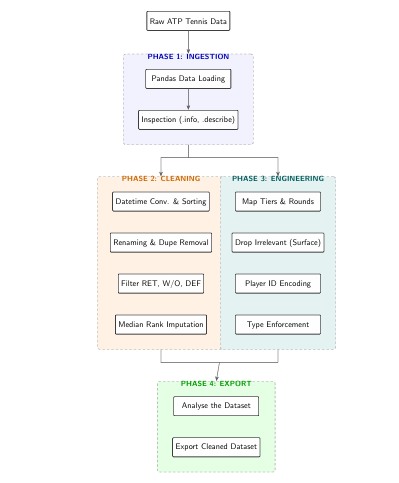

1. Covert Date Column to process matches chronologically

In [4]:
df['Match_Date'] = pd.to_datetime(df['Match_Date'])
df = df.sort_values('Match_Date').reset_index(drop=True)

In [5]:
df['Match_Date'].head()

0   2010-01-03
1   2010-01-03
2   2010-01-03
3   2010-01-03
4   2010-01-03
Name: Match_Date, dtype: datetime64[ns]

2. Rename variables according to the naming conventions.

In [6]:
df = df.rename(columns={
    
    'Match_Date':'date',
    'Tournament_Name': 'match_name',
    'Winner_Name ':'winner_name',
    'Winner_ID': 'winner_id',
    "Winner_Rank":'winner_rank',
    'Loser_name':'loser_name',
    'Loser_ID':'loser_id',
    "Loser_Rank": 'loser_rank'
       
})

In [7]:
df.head()

,date,match_name,Tournament_Tier,Prestige_Score,Round,Round_Name,Round_Multiplier,Match_Format,winner_id,Winner_Name,winner_rank,loser_id,Loser_Name,loser_rank,Score,Games_Diff,Sets_Diff,Surface,Best_of
0,2010-01-03,Brisbane,ATP 500,1.2,R32,Round of 32,0.4,Bo3,P_104053,Andy Roddick,7.0,P_103429,Peter Luczak,77.0,7-6(5) 6-2,4,1,Hard,3
1,2010-01-03,Brisbane,ATP 500,1.2,R32,Round of 32,0.4,Bo3,P_104639,Wayne Odesnik,105.0,P_103096,Arnaud Clement,63.0,6-4 7-6(2),2,1,Hard,3
2,2010-01-03,Brisbane,ATP 500,1.2,R32,Round of 32,0.4,Bo3,P_104268,Alejandro Falla,81.0,P_104871,Jeremy Chardy,32.0,6-4 6-4,4,2,Hard,3
3,2010-01-03,Brisbane,ATP 500,1.2,R32,Round of 32,0.4,Bo3,P_104792,Gael Monfils,13.0,P_103758,Taylor Dent,76.0,7-6(1) 6-7(5) 6-2,4,1,Hard,3
4,2010-01-03,Brisbane,ATP 500,1.2,R32,Round of 32,0.4,Bo3,P_103722,Florent Serra,65.0,P_104714,Julian Reister,173.0,6-7(3) 7-6(5) 7-5,2,1,Hard,3


3. Remove Duplicates
   

In [8]:
df = df.drop_duplicates()
print(df.shape)

(42570, 19)


4. Handeling missing values

In [9]:
df.isnull().sum().sort_values(ascending=False) 

loser_rank          671
winner_rank         262
Surface              53
Tournament_Tier       0
match_name            0
date                  0
Prestige_Score        0
Round_Multiplier      0
Match_Format          0
Round_Name            0
Round                 0
Winner_Name           0
winner_id             0
Loser_Name            0
loser_id              0
Score                 0
Games_Diff            0
Sets_Diff             0
Best_of               0
dtype: int64

According to the missing value observation, there are signnificant number of missing values in loser_rank and winner_rank. The missing values of the surface variable are neglected since does not affect the calculations of this research. 

In [10]:
# Check if winner_missing ranks are tied to specific tournament tiers
print(df[df['winner_rank'].isnull()]['Tournament_Tier'].value_counts())

Tournament_Tier
Davis Cup       245
ATP 500          14
Grand Slam        2
Masters 1000      1
Name: count, dtype: int64


In [11]:
#Check if loser_missing ranks are tied to specific tournament tiers
print(df[df['loser_rank'].isnull()]['Tournament_Tier'].value_counts())

Tournament_Tier
Davis Cup       580
ATP 500          69
Grand Slam       16
Masters 1000      3
ATP 250           3
Name: count, dtype: int64


This shows that the majority of missing values are from the Davis Cup. Hence, a contextual rank imputation should be carried out. 

- If we fill all the missing ranks with a slightly lower value than the lowest rank, regardless of the tournament, then the model misclassifies those players. Hence, missing values are filled with the median of seperate  rank of loser and winner, respectively, for each tournament category.

- STEPS 

1. Calculate the Median of loser rank and winner rank for each tournament tier. 
2. Fill the missing values with the specific median for each tournament tier.
3. Convert the ranks to integers. 
4. Check for any missing values after imputation.

  

In [12]:
##### Handelling the Missing Values of Loser Rank###########

# Calculate median ranks separately for winners and losers within each tier
winner_medians = df.groupby('Tournament_Tier')['winner_rank'].transform('median')
loser_medians = df.groupby('Tournament_Tier')['loser_rank'].transform('median')

# Fill the missing values using these specific series
df['winner_rank'] = df['winner_rank'].fillna(winner_medians)
df['loser_rank'] = df['loser_rank'].fillna(loser_medians)

# Convert to integers
df['winner_rank'] = df['winner_rank'].astype(int)
df['loser_rank'] = df['loser_rank'].astype(int)

#Check for missing values after imputation
print("Missing values in winner rank and loser rank")
print(df[['winner_rank','loser_rank']].isnull().sum())


Missing values in winner rank and loser rank
winner_rank    0
loser_rank     0
dtype: int64


In [13]:
df.isnull().sum().sort_values(ascending = False)

Surface             53
match_name           0
date                 0
Tournament_Tier      0
Prestige_Score       0
Round_Name           0
Round                0
Match_Format         0
winner_id            0
Winner_Name          0
Round_Multiplier     0
winner_rank          0
loser_id             0
loser_rank           0
Loser_Name           0
Score                0
Games_Diff           0
Sets_Diff            0
Best_of              0
dtype: int64

Since Surface is not a relevant column for this analysis, it is removed. 

In [14]:
df.drop('Surface',axis=1,inplace=True)
print(df.columns)

Index(['date', 'match_name', 'Tournament_Tier', 'Prestige_Score', 'Round',
       'Round_Name', 'Round_Multiplier', 'Match_Format', 'winner_id',
       'Winner_Name', 'winner_rank', 'loser_id', 'Loser_Name', 'loser_rank',
       'Score', 'Games_Diff', 'Sets_Diff', 'Best_of'],
      dtype='object')


5. Covert Data Types

In [15]:
#Check data types of each variable
print(df.dtypes)

date                datetime64[ns]
match_name                  object
Tournament_Tier             object
Prestige_Score             float64
Round                       object
Round_Name                  object
Round_Multiplier           float64
Match_Format                object
winner_id                   object
Winner_Name                 object
winner_rank                  int64
loser_id                    object
Loser_Name                  object
loser_rank                   int64
Score                       object
Games_Diff                   int64
Sets_Diff                    int64
Best_of                      int64
dtype: object


In [16]:
print("Unique Tournaments",df['Tournament_Tier'].unique())

Unique Tournaments ['ATP 500' 'Grand Slam' 'Davis Cup' 'Masters 1000' 'Tour Finals' 'ATP 250']


In [17]:
print("Unique tournament rounds", df['Round'].unique())

Unique tournament rounds ['R32' 'R16' 'SF' 'QF' 'F' 'R128' 'R64' 'RR' 'BR']


1. Convert winner_ID and loser_ID to category data type.
2. Map Tournament Tiers to numeric weights
- Grand Slam -6
- Tour Finals -5
- Masters 1000 -4
- Davis Cup -3
- ATP 500 - 2
- ATP 250 - 1
4. Map Rounds to numeric progression
- Final-9
- Semi-finals -8
- Quarter-finals -7
- Round of 16 -6
- Round of 32 -5
- Round of  64 -4
- Round of 128-3
- Round Robin -2
- Bronze Medal -1

In [18]:
# Convert ID to Category
df['winner_id'] = df['winner_id'].astype('category')
df['loser_id'] = df['loser_id'].astype('category')

# Map Tournament Tiers to numeric weights 
tier_mapping = {'Grand Slam': 6,'Tour Finals': 5, 'Masters 1000': 4, 'Davis Cup ': 3,'ATP 500': 2, 'ATP 250': 1}
df['tier_num'] = df['Tournament_Tier'].map(tier_mapping)

# Map Rounds to numeric progression
round_mapping = {'BR': 1,'RR': 2,'R128': 3, 'R64': 4, 'R32': 5, 'R16': 6, 'QF': 7, 'SF': 8, 'F': 9}
df['round_num'] = df['Round'].map(round_mapping)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42570 entries, 0 to 42570
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              42570 non-null  datetime64[ns]
 1   match_name        42570 non-null  object        
 2   Tournament_Tier   42570 non-null  object        
 3   Prestige_Score    42570 non-null  float64       
 4   Round             42570 non-null  object        
 5   Round_Name        42570 non-null  object        
 6   Round_Multiplier  42570 non-null  float64       
 7   Match_Format      42570 non-null  object        
 8   winner_id         42570 non-null  category      
 9   Winner_Name       42570 non-null  object        
 10  winner_rank       42570 non-null  int64         
 11  loser_id          42570 non-null  category      
 12  Loser_Name        42570 non-null  object        
 13  loser_rank        42570 non-null  int64         
 14  Score             42570 non

6. Clean the Matches with the following scores
- RET: Retirement (a player stopped mid-match due to injury).

- W/O: Walkover (a player didn't show up).

- DEF: Default (a player was disqualified).

In [19]:
# Create a mask to find the matches with the unwanted scores. 
score_wrong_mask = df['Score'].str.contains('RET|W/O|DEF', na=False)

# Filter the dataframe to see these specific rows
wrong_matches = df[score_wrong_mask]

# Print the specific columns
print(wrong_matches[['winner_id', 'loser_id', 'Score', 'Tournament_Tier']])

      winner_id  loser_id            Score Tournament_Tier
71     P_103794  P_104230          5-1 RET         ATP 500
83     P_104745  P_104327      6-1 2-0 RET         ATP 500
107    P_103967  P_103507          3-1 RET         ATP 500
131    P_103808  P_104593      6-3 3-2 RET         ATP 500
150    P_103970  P_104523  6-0 6-0 2-0 RET      Grand Slam
...         ...       ...              ...             ...
42402  P_200282  P_207925   7-6(2) 3-1 RET         ATP 500
42438  P_126239  P_207830   6-7(3) 5-3 RET    Masters 1000
42505  P_144895  P_126094              W/O         ATP 500
42523  P_144895  P_111576      7-5 4-0 RET         ATP 500
42569  P_210506  P_209992      4-1 1-1 RET     Tour Finals

[1506 rows x 4 columns]


In [20]:
# Delete the rows of matches with the unwanted scores. 
df = df[df['Score'].notna()]
df = df[~df['Score'].str.contains('RET|W/O|DEF', na=False)]

In [21]:
##CHEKS##
has_unwanted = df['Score'].str.contains('RET|W/O|DEF', na=False).any()

if has_unwanted:
    print("Warning: Unwanted scores still found in dataset")
else:
    print("Success: No unwanted scores remain in  dataset.")
    print(df.shape)

Success: No unwanted scores remain in  dataset.
(41064, 20)


7. Pre-processing for winner_ID and loser_ID
- Get a unique list of all players from both winners and losers
- Map IDs to an integer index
- Apply the mapping to dataset

In [22]:
#Get a unique list of all players from both winners and losers
all_players = pd.unique(df[['winner_id', 'loser_id']].values.ravel())
print("Unique Players", len(all_players))

# Map IDs to an integer index
player_to_int = {player_id: i for i, player_id in enumerate(all_players)}
int_to_player = {i: player_id for i, player_id in enumerate(all_players)}

# Apply the mapping to  df_std
df['winner_id_int'] = df['winner_id'].map(player_to_int)
df['loser_id_int'] = df['loser_id'].map(player_to_int)


1633
['P_210025' 'P_210494' 'P_210460']


In [23]:
print(df[['winner_id','winner_id_int','loser_id','loser_id_int']].tail())

      winner_id  winner_id_int  loser_id  loser_id_int
42565  P_211663         1509.0  P_210530        1431.0
42566  P_211663         1509.0  P_209414        1468.0
42567  P_210530         1431.0  P_210506        1523.0
42568  P_209950         1470.0  P_210150        1530.0
42570  P_211663         1509.0  P_209950        1470.0


In [24]:
# Ensure the IDs are integers for indexing
df['winner_id_int'] = df['winner_id_int'].astype(int)
df['loser_id_int'] = df['loser_id_int'].astype(int)

# Check 
print(df[['winner_id_int', 'loser_id_int']].dtypes)

winner_id_int    int64
loser_id_int     int64
dtype: object


In [25]:
df.info()

<bound method DataFrame.info of             date       match_name Tournament_Tier  Prestige_Score Round  \
0     2010-01-03         Brisbane         ATP 500             1.2   R32   
1     2010-01-03         Brisbane         ATP 500             1.2   R32   
2     2010-01-03         Brisbane         ATP 500             1.2   R32   
3     2010-01-03         Brisbane         ATP 500             1.2   R32   
4     2010-01-03         Brisbane         ATP 500             1.2   R32   
...          ...              ...             ...             ...   ...   
42565 2024-12-18  Next Gen Finals     Tour Finals             1.8     F   
42566 2024-12-18  Next Gen Finals     Tour Finals             1.8    SF   
42567 2024-12-18  Next Gen Finals     Tour Finals             1.8    SF   
42568 2024-12-18  Next Gen Finals     Tour Finals             1.8    RR   
42570 2024-12-18  Next Gen Finals     Tour Finals             1.8    RR   

        Round_Name  Round_Multiplier Match_Format winner_id      Wi

8. Extracting necessary columns to create the standard ELO dataset.
To calculate the standard Elo model, we need the following parameters.
-  

In [26]:
# Create the subset dataframe for the Standard Elo Model
df_std = df[['date', 'winner_id','winner_id_int', 'loser_id','loser_id_int', 'winner_rank', 'loser_rank']].copy()

# Sort by date to ensure the Elo algorithm processes matches in the correct order
df_std = df_std.sort_values(by='date').reset_index(drop=True)
print(df_std.tail())

            date winner_id  winner_id_int  loser_id  loser_id_int  \
41059 2024-12-18  P_211663           1509  P_210530          1431   
41060 2024-12-18  P_211663           1509  P_209414          1468   
41061 2024-12-18  P_210530           1431  P_210506          1523   
41062 2024-12-18  P_209950           1470  P_210150          1530   
41063 2024-12-18  P_211663           1509  P_209950          1470   

       winner_rank  loser_rank  
41059          145         122  
41060          145         128  
41061          122          41  
41062           20          48  
41063          145          20  


In [27]:
print(df_std.info())
print(df_std.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41064 entries, 0 to 41063
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           41064 non-null  datetime64[ns]
 1   winner_id      41064 non-null  category      
 2   winner_id_int  41064 non-null  int64         
 3   loser_id       41064 non-null  category      
 4   loser_id_int   41064 non-null  int64         
 5   winner_rank    41064 non-null  int64         
 6   loser_rank     41064 non-null  int64         
dtypes: category(2), datetime64[ns](1), int64(4)
memory usage: 1.8 MB
None
(41064, 7)


### Standard Elo Dataset feature visualisation 

Visualizations saved as: correlation_heatmap.png, rank_distributions.png, rank_relationship.png


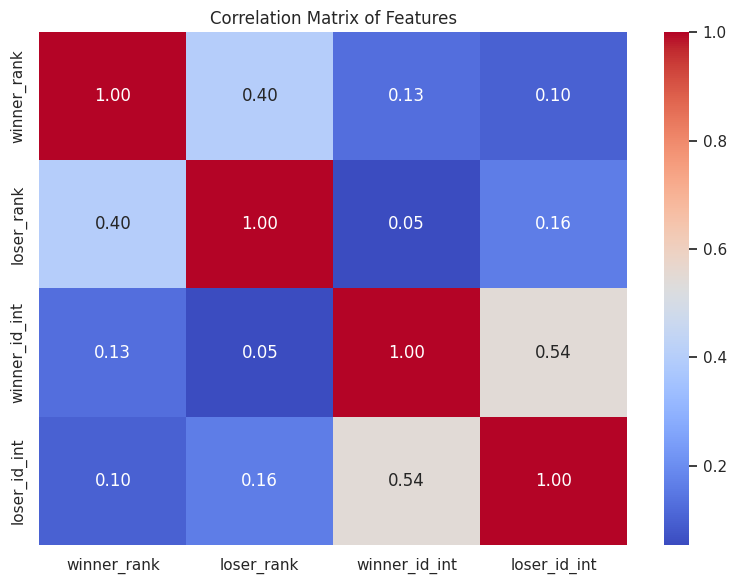

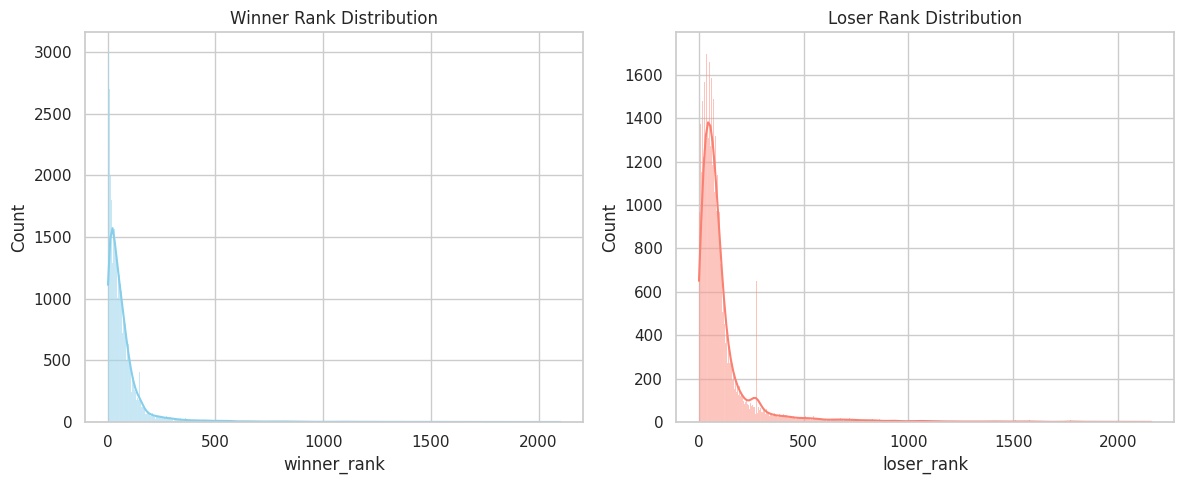

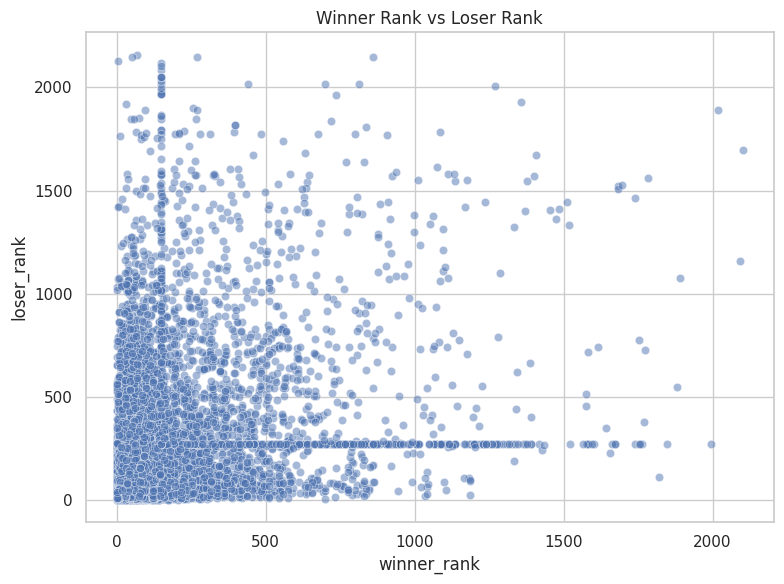

In [28]:
# Set the visual style
sns.set_theme(style="whitegrid")

# This tells if there's any surprising relationship between ranks and IDs
plt.figure(figsize=(8, 6))
correlation_matrix = df_std[['winner_rank', 'loser_rank', 'winner_id_int', 'loser_id_int']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

# check whether the data is skewed towards lower or higher ranked players
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_std['winner_rank'], ax=axes[0], kde=True, color='skyblue')
axes[0].set_title('Winner Rank Distribution')
sns.histplot(df_std['loser_rank'], ax=axes[1], kde=True, color='salmon')
axes[1].set_title('Loser Rank Distribution')
plt.tight_layout()
plt.savefig('rank_distributions.png')

# Visualise the compettitiveness among matches
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_std, x='winner_rank', y='loser_rank', alpha=0.5)
plt.title("Winner Rank vs Loser Rank")
plt.tight_layout()
plt.savefig('rank_relationship.png')

print("Visualizations saved as: correlation_heatmap.png, rank_distributions.png, rank_relationship.png")

In [29]:
# Save the Original Cleaned dataframe to a CSV file
df.to_csv('cleaned_tennis_data.csv', index=False)

In [30]:
# Save the dataframe to a CSV file in your current working directory
df_std.to_csv('Standard_Elo_dataset.csv', index=False)

In [35]:
print(df.describe())

                                date  Prestige_Score  Round_Multiplier  \
count                          41064    41064.000000      41064.000000   
mean   2017-04-17 01:25:17.007598080        1.410540          0.481026   
min              2010-01-03 00:00:00        1.000000          0.250000   
25%              2013-06-10 00:00:00        1.200000          0.300000   
50%              2017-02-20 00:00:00        1.200000          0.400000   
75%              2021-05-17 00:00:00        1.500000          0.650000   
max              2024-12-18 00:00:00        2.000000          1.000000   
std                              NaN        0.297269          0.182392   

        winner_rank    loser_rank    Games_Diff     Sets_Diff      Best_of  \
count  41064.000000  41064.000000  41064.000000  41064.000000  41064.00000   
mean      75.603059    115.563024      4.802503      1.519944      3.43532   
min        1.000000      1.000000     -8.000000     -2.000000      3.00000   
25%       17.000000  